In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy import fft, signal

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

Filters have many applications in sound synthesis and signal processing. Their basic job is to shape the spectrum of a signal by emphasizing or supressing frequencies. They are the essential component in subtractive synthesis and their individual qualities are responsible for an instrument's distincive sound. Famous filter designs, like the Moog Ladder Filter, are thus standards in the design of analog and digital musical instruments.

Regardless of the implementation details, both analog and digital filters can be categorized by their filter characteristics. These describe, which frequency components of the signal are passed through and which frequencies are rejected. This section describes some of the most frequently used filer types.

-----

# Parameters and Properties

- The **pass-band** is that region of the spectrum that is not filtered out - it passes.

- The **stop-band** is the region of the spectrum that is suppressed by the filter.

- The **filter slope** is the slope between pass-band and stop-band.

- The central parameter for most filter types is the **cutoff frequency** $f_c$. Depending on the characteristic, the cutoff frequency is that frequency which separates pass-band and stop-band. It is located at the $-3 \mathrm{dB}$ point of the slope.

- Some filters have a **center frequency** - see band pass and band stop.


------

# Filter Characteristics


Filters are characterized by their impulse response or its Fourier transform  - the Frequency response.
The Frequency response is complex and can be separated into the **magnitude response** and the **phase response**.
For most applications, the magnitude response the most important characteristic.
It is visualized in the **Bode plot**, with the logarithmic gain plotted over the logarithmic freuency.




-----

## Lowpass

The lowpass filter (LP) is the most frequently used characteristic in sound synthesis.
It is used for the typical bass sounds known from analog and digital subtractive synthesis. With the right envelope settings, it creates the plucked sounds.
An LP filter lets all frequencies below the cutoff frequency *pass*. 
$f_c$ is defined as that frequency where the gain of the filter is $-3\ \mathrm{dB}$, which is equivalent to $50\ \%$.
The following plot shows the frequency-dependent gain of a lowpass with a cutoff at $100\ \mathrm{Hz}$.

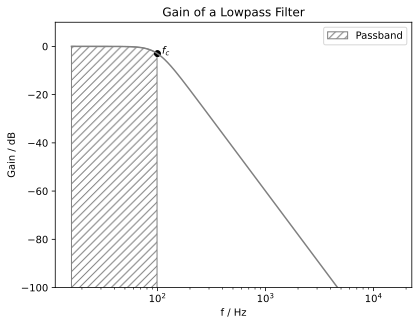

In [2]:


fs = 16000 
fc = 100
N  = 10000

f  = np.linspace(0.001,1,N)

b, a = signal.iirfilter(3, fc/fs, btype='lowpass', analog=True, ftype='butter')

w, h = signal.freqs(b, a, f)

f = f*fs;

H =  20 * np.log10(abs(h))

plt.semilogx(f , H,color=[0.5,0.5,0.5]);

plt.xlabel('f / Hz');
plt.ylabel('Gain / dB');

cutInd = round((0.33*fs/fc));

plt.fill_between(f[0:cutInd], H[0:cutInd], -120,color='none',hatch="///",edgecolor="gray",label='Passband');

plt.scatter(fc, -3, marker='o', color='k');
plt.text(fc+10, -3, '$f_c$',horizontalalignment='left');

plt.ylim([-100,10]);

plt.title('Gain of a Lowpass Filter');
plt.legend();



----

## Highpass Filter

The highpass (HP) filter is the opposite of the lowpass filter. It rejects low frequencies and lets high frequencies *pass*. 
The following plot shows the frequency-dependent gain of a highpass with a cutoff at $100\ \mathrm{Hz}$.




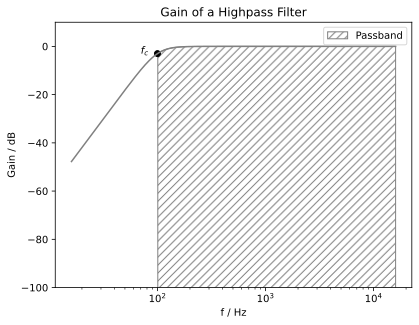

In [3]:


fs = 16000 
fc = 100
N  = 10000

f  = np.linspace(0.001,1,N)

b, a = signal.iirfilter(3, fc/fs, btype='highpass', analog=True, ftype='butter')

w, h = signal.freqs(b, a, f)

f = f*fs;

H =  20 * np.log10(abs(h))

plt.semilogx(f , H,color=[0.5,0.5,0.5]);

plt.xlabel('f / Hz');
plt.ylabel('Gain / dB');

cutInd = round((0.33*fs/fc));

plt.fill_between(f[cutInd:-1], H[cutInd:-1], -120,color='none',hatch="///",edgecolor="gray",label='Passband');

plt.scatter(fc, -3, marker='o', color='k');
plt.text(fc-30, -3, '$f_c$',horizontalalignment='left');

plt.ylim([-100,10]);

plt.title('Gain of a Highpass Filter');
plt.legend();



-----

## Bandpass Filter

The bandbass (BP) filter is a combination of lowpass and highpass. It lets frequencies between a lower cutoff frequency $f_{low}$ and an upper cutoff frequency $f_{up}$ *pass*. The BP filter can thus also be defined by its center frequency

$$f_{cent} = \frac{f_{up}+f_{low}}{2}$$

and the bandwith 

$$\mathrm{BW} = f_{up}-f_{low}$$

Another common characteristic is the quality - the reciprocal of the normalized bandwidth:

$$Q=\frac{f_{cent}}{f_{up}-f_{low}}$$



The following plot shows a bandpass with a center frequency of $f_{cent} = 100\ \mathrm{Hz}$ and a bandwidht of $50\ \mathrm{Hz}$.

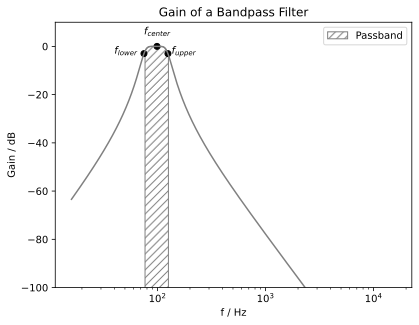

In [4]:

fs = 16000 

fc1 = 75
fc2 = 125

N  = 10000

f  = np.linspace(0.001,1,N)

b, a = signal.iirfilter(3, [fc1/fs, fc2/fs], btype='bandpass', analog=True, ftype='butter')

w, h = signal.freqs(b, a, f)

f = f*fs;

H =  20 * np.log10(abs(h))

plt.semilogx(f , H,color=[0.5,0.5,0.5]);

plt.xlabel('f / Hz');
plt.ylabel('Gain / dB');

cutInd1 = round((0.33*fs/fc1));
cutInd2 = round((0.30*fs/fc2));

plt.fill_between(f[cutInd2:cutInd1], H[cutInd2:cutInd1], -120,color='none',hatch="///",edgecolor="gray",label='Passband');

plt.scatter(fc2, -3, marker='o', color='k');
plt.text(fc2+10, -3, '$f_{upper}$',horizontalalignment='left',color='k');

plt.scatter(fc1, -3, marker='o', color='k');
plt.text(fc1-10, -3, '$f_{lower}$',horizontalalignment='right',color='k');


plt.scatter(round(0.5*(fc2+fc1))-1, 0, marker='o', color='k');
plt.text(fc1, 5, '$f_{center}$',horizontalalignment='left',color='k');

plt.ylim([-100,10]);

plt.title('Gain of a Bandpass Filter');
plt.legend();



------

## Band Stop / Band Reject

The band stop filter is the inverse of a band-pass - it supresses the frequencies between an upper and a lower cutoff frequency:


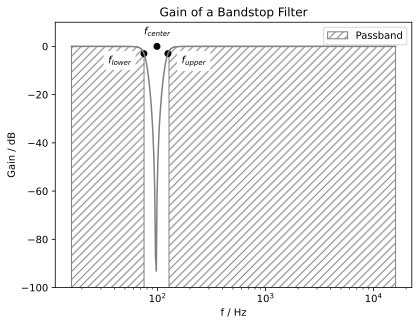

In [5]:
# load relevant modules from header file
%run header.ipynb

fs = 16000 

fc1 = 75
fc2 = 125

N  = 10000

f  = np.linspace(0.001,1,N)

b, a = signal.iirfilter(3, [fc1/fs, fc2/fs], btype='bandstop', analog=True, ftype='butter')

w, h = signal.freqs(b, a, f)

f = f*fs;

H =  20 * np.log10(abs(h))

plt.semilogx(f , H,color=[0.5,0.5,0.5]);

plt.xlabel('f / Hz');
plt.ylabel('Gain / dB');

cutInd1 = round((0.33*fs/fc1));
cutInd2 = round((0.30*fs/fc2));

plt.fill_between(f[0:cutInd2], H[0:cutInd2], -120,color='none',hatch="///",edgecolor="gray",label='Passband');
plt.fill_between(f[cutInd1:-1], H[cutInd1:-1], -120,color='none',hatch="///",edgecolor="gray");

plt.scatter(fc2, -3, marker='o', color='k');
plt.text(fc2+42, -7, '$f_{upper}$',horizontalalignment='left',color='k',backgroundcolor='w');

plt.scatter(fc1, -3, marker='o', color='k');
plt.text(fc1-18, -7, '$f_{lower}$',horizontalalignment='right',color='k',backgroundcolor='w')

plt.scatter(round(0.5*(fc2+fc1))-1, 0, marker='o', color='k');
plt.text(fc1, 5, '$f_{center}$',horizontalalignment='left',color='k');

plt.ylim([-100,10]);

plt.title('Gain of a Bandstop Filter');
plt.legend();



------

## Allpass

Allpass filters do not change the magnitue spectrum of signals.
Hence, their magnitude response is flat.
However, they change the signals characteristic in the phase domain.
This can for exmample be used in artificial reverb.


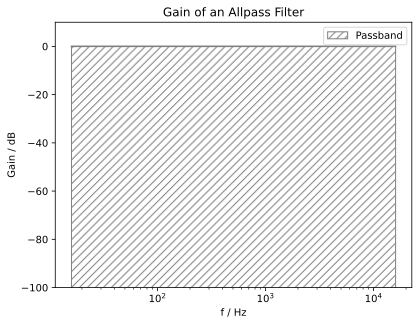

In [6]:


fs = 16000 

fc1 = 75
fc2 = 125

N  = 10000

f  = np.linspace(0.001,1,N)

#b, a = signal.iirfilter(3, [fc1/fs, fc2/fs], btype='bandstop', analog=True, ftype='butter')

b=[1,0]
a=[0,1,0]

w, h = signal.freqs(b, a, f)

f = f*fs;

H =  20 * np.log10(abs(h))

plt.semilogx(f , H,color=[0.5,0.5,0.5]);

plt.xlabel('f / Hz');
plt.ylabel('Gain / dB');

cutInd1 = round((0.33*fs/fc1));
cutInd2 = round((0.30*fs/fc2));

plt.fill_between(f[0:-1], H[0:-1], -120,color='none',hatch="///",edgecolor="gray",label='Passband');



plt.ylim([-100,10]);

plt.title('Gain of an Allpass Filter');
plt.legend();
